<a href="https://colab.research.google.com/github/Kiran111L/llm-microservices-project/blob/main/TEXT_SUMMARIZATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.0 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras import backend as K
from tensorflow.keras.layers import LSTM, TimeDistributed, Dense, Embedding, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model, Model
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings, re
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tqdm.notebook import tqdm
from wordcloud import WordCloud
tqdm.pandas()
logger = tf.get_logger()
from tensorflow.keras.utils import plot_model
from nltk.translate.bleu_score import sentence_bleu
from jiwer import wer, mer, cer, wip, wil

In [ ]:
plt.rcParams['figure.figsize'] = (12,8)

In [ ]:
import pandas as pd

# Load datasets
df1 = pd.read_csv('news_summary_more.csv', encoding='latin-1')
df2 = pd.read_csv('news_summary.csv', encoding='latin-1')

# Keep only 'headlines' and 'text' columns
df1 = df1[['headlines', 'text']]
df2 = df2[['headlines', 'text']]

# Concatenate datasets
df = pd.concat([df1, df2], ignore_index=True)

# Sample 8000 rows
df = df.sample(n=8000, random_state=42).reset_index(drop=True)

# Check the shape and first few rows
print(df.shape)  # Should be (8000, 2)
print(df.head())


(8000, 2)
                                           headlines  \
0  French citizenship for migrant who saved kid h...   
1  SpaceX to lay off over 600 workers to become a...   
2  Nirmal Soni to play Dr Hathi after Kavi's demi...   
3  Monkeys drop bag containing crude bombs in UP,...   
4  Delhi University gives student parties 36hrs t...   

                                                text  
0  French President Emmanuel Macron on Monday ann...  
1  Billionaire Elon Musk-led SpaceX has announced...  
2  Actor Nirmal Soni will portray the role of Dr ...  
3  Three people including a kid were severely inj...  
4  Ahead of Students' Union elections, the Delhi ...  


In [ ]:
df.shape

(8000, 2)

In [ ]:
df.isna().sum()

,0
headlines,0
text,0


In [ ]:
df = df.dropna()
df.shape

(8000, 2)

In [ ]:
df.duplicated().sum()

np.int64(17)

In [ ]:
df = df.drop_duplicates()
df.shape

(7983, 2)

In [ ]:
df['text_len'] = df.text.apply(len)
df['headlines_len'] = df.headlines.apply(len)

<Axes: xlabel='headlines_len', ylabel='Density'>

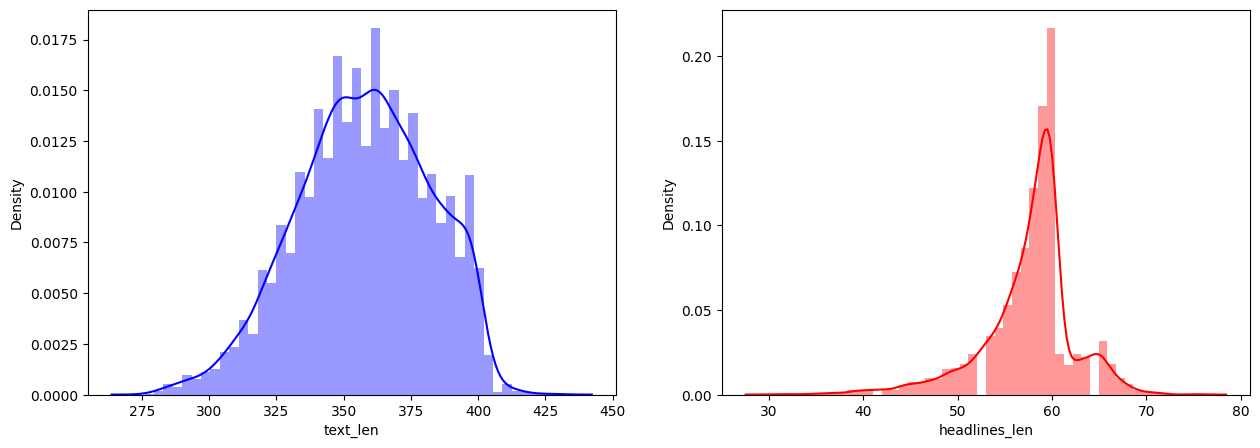

In [ ]:
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(15,5))
sns.distplot(df.text_len,ax=axes[0],color='blue')
sns.distplot(df.headlines_len,ax=axes[1],color='red')

In [ ]:
df.describe()


,text_len,headlines_len
count,7983.000000,7983.000000
mean,357.506201,57.578605
std,24.679863,4.921107
min,276.000000,30.000000
25%,341.000000,56.000000
50%,358.000000,59.000000
75%,376.000000,60.000000
max,430.000000,76.000000


In [ ]:
max_text_len = 350
max_headline_len = 50

In [ ]:
df.headlines = df.headlines.apply(lambda x: '<START> ' + x + ' <END>')

In [ ]:
def clean_text(text):
    text = text.lower().strip()
    # Replace certain special characters with their string equivalents
    text = text.replace('%', ' percent')
    text = text.replace('$', ' dollar ')
    text = text.replace('₹', ' rupee ')
    text = text.replace('€', ' euro ')
    text = text.replace('@', ' at ')
    text = text.replace(',000,000,000 ', 'b ')
    text = text.replace(',000,000 ', 'm ')
    text = text.replace(',000 ', 'k ')
    text = re.sub(r'([0-9]+)000000000', r'\1b', text)
    text = re.sub(r'([0-9]+)000000', r'\1m', text)
    text = re.sub(r'([0-9]+)000', r'\1k', text)

    contractions = {
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    text_decontracted = []

    for word in text.split():
        if word in contractions:
            word = contractions[word]

        text_decontracted.append(word)

    text = ' '.join(text_decontracted)
    text = text.replace("'ve", " have")
    text = text.replace("n't", " not")
    text = text.replace("'re", " are")
    text = text.replace("'ll", " will")
    text = re.sub(r"i'm", "i am", text)
    text = re.sub(r"he's", "he is", text)
    text = re.sub(r"she's", "she is", text)
    text = re.sub(r"it's", "it is", text)
    text = re.sub(r"that's", "that is", text)
    text = re.sub(r"what's", "that is", text)
    text = re.sub(r"where's", "where is", text)
    text = re.sub(r"how's", "how is", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"n'", "ng", text)
    text = re.sub(r"'bout", "about", text)
    text = re.sub(r"'til", "until", text)
    text = re.sub(r"[-()\"#/@;:<>{}`+=~|.!?,]", "", text)
    pattern = re.compile('\W')
    text = re.sub(pattern, ' ', text).strip()
    return text

In [ ]:
df.text = df.text.progress_apply(clean_text)
df.headlines = df.headlines.progress_apply(clean_text)

  0%|          | 0/7983 [00:00<?, ?it/s]

  0%|          | 0/7983 [00:00<?, ?it/s]

In [ ]:
df.head()

,headlines,text,text_len,headlines_len
0,start french citizenship for migrant who saved...,french president emmanuel macron on monday ann...,351,65
1,start spacex to lay off over 600 workers to be...,billionaire elon muskled spacex has announced ...,398,63
2,start nirmal soni to play dr hathi after kavi ...,actor nirmal soni will portray the role of dr ...,323,57
3,start monkeys drop bag containing crude bombs ...,three people including a kid were severely inj...,344,56
4,start delhi university gives student parties 3...,ahead of students union elections the delhi u...,370,60


In [ ]:
x_tokenizer = Tokenizer()
x_tokenizer.fit_on_texts(df.text)

In [ ]:
text_vocab_length = len(x_tokenizer.index_word) + 1
text_vocab_length

32292

In [ ]:
text_sequences = x_tokenizer.texts_to_sequences(df.text)
text_pad_sequences = pad_sequences(text_sequences,maxlen=max_text_len,padding='post')

In [ ]:
y_tokenizer = Tokenizer()
y_tokenizer.fit_on_texts(df.headlines)

In [ ]:
headline_vocab_length = len(y_tokenizer.index_word) + 1
headline_vocab_length

13454

In [ ]:
headline_sequences = y_tokenizer.texts_to_sequences(df.headlines)
headline_pad_sequences = pad_sequences(headline_sequences,maxlen=max_headline_len,padding='post')

In [ ]:
class AttentionLayer(tf.keras.layers.Layer):
    """
    This class implements Bahdanau attention (https://arxiv.org/pdf/1409.0473.pdf).
    There are three sets of weights introduced W_a, U_a, and V_a
     """

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        assert isinstance(input_shape, list)
        # Create a trainable weight variable for this layer.

        self.W_a = self.add_weight(name='W_a',
                                   shape=tf.TensorShape((input_shape[0][2], input_shape[0][2])),
                                   initializer='uniform',
                                   trainable=True)
        self.U_a = self.add_weight(name='U_a',
                                   shape=tf.TensorShape((input_shape[1][2], input_shape[0][2])),
                                   initializer='uniform',
                                   trainable=True)
        self.V_a = self.add_weight(name='V_a',
                                   shape=tf.TensorShape((input_shape[0][2], 1)),
                                   initializer='uniform',
                                   trainable=True)

        super(AttentionLayer, self).build(input_shape)  # Be sure to call this at the end

    def call(self, inputs):
        """
        inputs: [encoder_output_sequence, decoder_output_sequence]
        """
        assert type(inputs) == list
        encoder_out_seq, decoder_out_seq = inputs

        logger.debug(f"encoder_out_seq.shape = {encoder_out_seq.shape}")
        logger.debug(f"decoder_out_seq.shape = {decoder_out_seq.shape}")

        def energy_step(inputs, states):
            """ Step function for computing energy for a single decoder state
            inputs: (batchsize * 1 * de_in_dim)
            states: (batchsize * 1 * de_latent_dim)
            """

            logger.debug("Running energy computation step")

            if not isinstance(states, (list, tuple)):
                raise TypeError(f"States must be an iterable. Got {states} of type {type(states)}")

            encoder_full_seq = states[-1]

            """ Computing S.Wa where S=[s0, s1, ..., si]"""
            # <= batch size * en_seq_len * latent_dim
            W_a_dot_s = K.dot(encoder_full_seq, self.W_a)

            """ Computing hj.Ua """
            U_a_dot_h = K.expand_dims(K.dot(inputs, self.U_a), 1)  # <= batch_size, 1, latent_dim

            logger.debug(f"U_a_dot_h.shape = {U_a_dot_h.shape}")

            """ tanh(S.Wa + hj.Ua) """
            # <= batch_size*en_seq_len, latent_dim
            Ws_plus_Uh = K.tanh(W_a_dot_s + U_a_dot_h)

            logger.debug(f"Ws_plus_Uh.shape = {Ws_plus_Uh.shape}")

            """ softmax(va.tanh(S.Wa + hj.Ua)) """
            # <= batch_size, en_seq_len
            e_i = K.squeeze(K.dot(Ws_plus_Uh, self.V_a), axis=-1)
            # <= batch_size, en_seq_len
            e_i = K.softmax(e_i)

            logger.debug(f"ei.shape = {e_i.shape}")

            return e_i, [e_i]

        def context_step(inputs, states):
            """ Step function for computing ci using ei """

            logger.debug("Running attention vector computation step")

            if not isinstance(states, (list, tuple)):
                raise TypeError(f"States must be an iterable. Got {states} of type {type(states)}")

            encoder_full_seq = states[-1]

            # <= batch_size, hidden_size
            c_i = K.sum(encoder_full_seq * K.expand_dims(inputs, -1), axis=1)

            logger.debug(f"ci.shape = {c_i.shape}")

            return c_i, [c_i]

        # we don't maintain states between steps when computing attention
        # attention is stateless, so we're passing a fake state for RNN step function
        fake_state_c = K.sum(encoder_out_seq, axis=1)
        fake_state_e = K.sum(encoder_out_seq, axis=2)  # <= (batch_size, enc_seq_len, latent_dim

        """ Computing energy outputs """
        # e_outputs => (batch_size, de_seq_len, en_seq_len)
        last_out, e_outputs, _ = K.rnn(
            energy_step, decoder_out_seq, [fake_state_e], constants=[encoder_out_seq]
        )

        """ Computing context vectors """
        last_out, c_outputs, _ = K.rnn(
            context_step, e_outputs, [fake_state_c], constants=[encoder_out_seq]
        )

        return c_outputs, e_outputs

    def compute_output_shape(self, input_shape):
        """ Outputs produced by the layer """
        return [
            tf.TensorShape((input_shape[1][0], input_shape[1][1], input_shape[1][2])),
            tf.TensorShape((input_shape[1][0], input_shape[1][1], input_shape[0][1]))
        ]

In [ ]:
K.clear_session()

latent_dim = 300
embedding_dim = 100

encoder_inputs = Input(shape=(max_text_len,))
encoder_emb = Embedding(text_vocab_length, embedding_dim, trainable=True)(encoder_inputs)

encoder_lstm1 = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.3, recurrent_dropout=0.2)
encoder_output1, state_h1, state_c1 = encoder_lstm1(encoder_emb)

encoder_lstm2 = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.3, recurrent_dropout=0.2)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1)

encoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.3, recurrent_dropout=0.2)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_output2)
encoder_states = [state_h,state_c]

decoder_inputs = Input(shape=(None,))
decoder_emb = Embedding(headline_vocab_length, embedding_dim, trainable=True)(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.3, recurrent_dropout=0.2)
decoder_outputs, decoder_fwd_state, decoder_bwd_state = decoder_lstm(decoder_emb, initial_state=encoder_states)

attn_layer = AttentionLayer(name='attention_layer')
attn_outputs, attn_states = attn_layer([encoder_outputs, decoder_outputs])

decoder_concat_outputs = Concatenate(axis=-1,name='concat_layer')([decoder_outputs, attn_outputs])

decoder_dense = TimeDistributed(Dense(headline_vocab_length,activation='softmax'))
decoder_outputs = decoder_dense(decoder_concat_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 350)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 350, 100)  │  3,229,200 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 350,      │    481,200 │ embedding[0][0]   │
│                     │ 300), (None,      │            │                   │
│                     │ 300), (None,      │            │                   │
│                     │ 300)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 350,      │    721,200 │ lstm[0][0]        │
│                     │ 300), (None,      │            │                   │
│                     │ 300), (None,      │            │                   │
│                     │ 300)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 100) │  1,345,400 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 350,      │    721,200 │ lstm_1[0][0]      │
│                     │ 300), (None,      │            │                   │
│                     │ 300), (None,      │            │                   │
│                     │ 300)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, None,     │    481,200 │ embedding_1[0][0… │
│                     │ 300), (None,      │            │ lstm_2[0][1],     │
│                     │ 300), (None,      │            │ lstm_2[0][2]      │
│                     │ 300)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ [(None, None,     │    180,300 │ lstm_2[0][0],     │
│ (AttentionLayer)    │ 300), (None,      │            │ lstm_3[0][0]      │
│                     │ None, 350)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_layer        │ (None, None, 600) │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, None,      │  8,085,854 │ concat_layer[0][… │
│ (TimeDistributed)   │ 13454)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,245,554 (58.16 MB)

 Trainable params: 15,245,554 (58.16 MB)

 Non-trainable params: 0 (0.00 B)

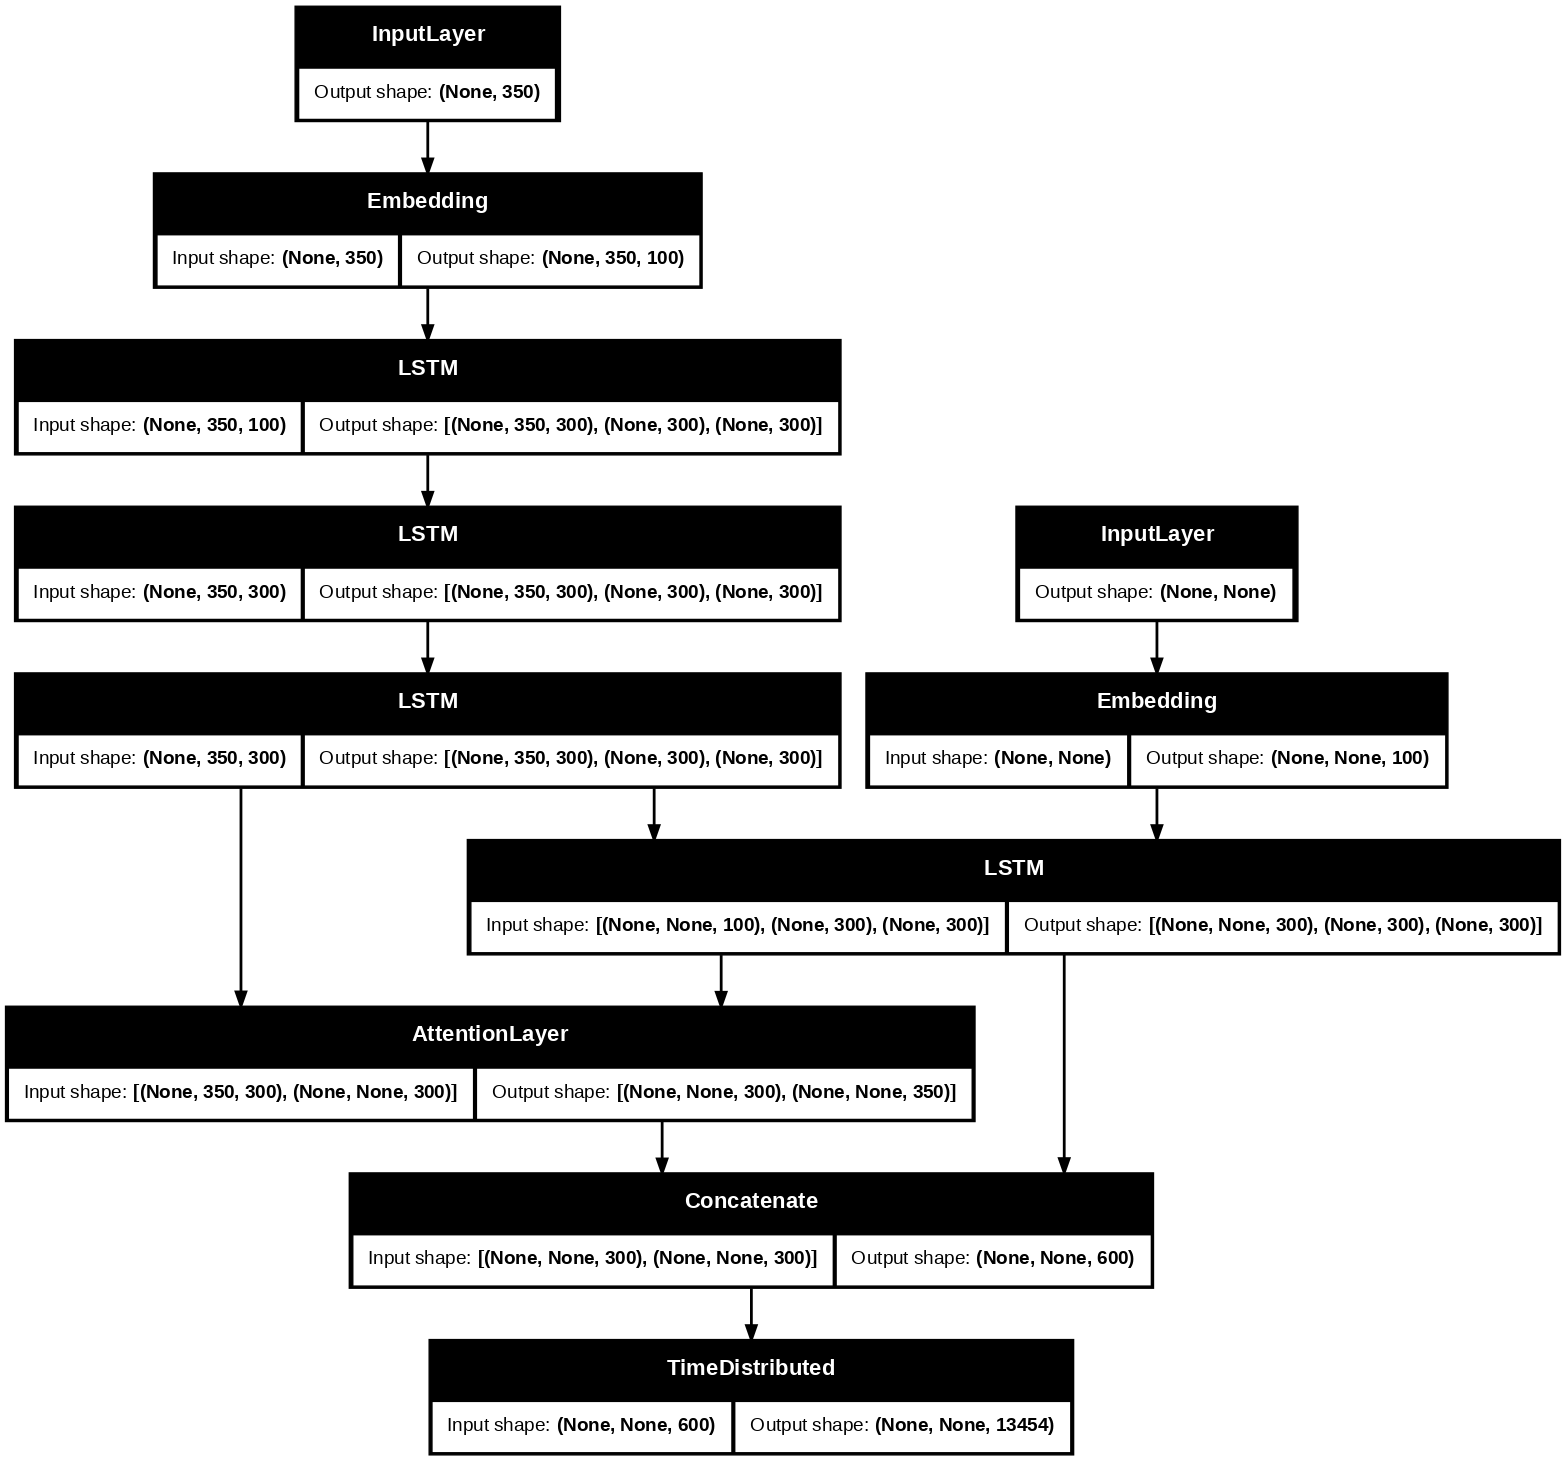

In [ ]:
plot_model(model,'model.png',show_shapes=True,dpi=100)

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='rmsprop',metrics=['accuracy'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(text_pad_sequences,headline_pad_sequences,test_size=0.25,shuffle=True,random_state=101)

In [ ]:
es = EarlyStopping(monitor='val_accuracy',mode='max',verbose=1,patience=40)
rl = ReduceLROnPlateau(monitor='val_accuracy',mode='max',verbose=1,patience=5,factor=0.1,min_lr=0.001)
mc = ModelCheckpoint('checkpoint/best_model.keras',monitor='val_accuracy',verbose=1,mode='max',save_best_only=True)

r = model.fit([X_train,y_train[:,:-1]],
             y_train.reshape(y_train.shape[0],y_train.shape[1],1)[:,1:],
             epochs=50,
             batch_size=128,
             callbacks=[es,rl,mc],
             validation_data=([X_test,y_test[:,:-1]],y_test.reshape(y_test.shape[0],y_test.shape[1],1)[:,1:]))

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7037 - loss: 4.2611
Epoch 1: val_accuracy improved from -inf to 0.78155, saving model to checkpoint/best_model.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 247s 5s/step - accuracy: 0.7049 - loss: 4.2261 - val_accuracy: 0.7816 - val_loss: 1.7652 - learning_rate: 0.0010
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7832 - loss: 1.7252
Epoch 2: val_accuracy improved from 0.78155 to 0.79110, saving model to checkpoint/best_model.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 217s 5s/step - accuracy: 0.7832 - loss: 1.7250 - val_accuracy: 0.7911 - val_loss: 1.7049 - learning_rate: 0.0010
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7891 - loss: 1.6716
Epoch 3: val_accuracy improved from 0.79110 to 0.80055, saving model to checkpoint/best_model.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 217s 5s/step - accuracy: 0.7892 - loss: 1.6715 - val_accuracy: 0.8006 - val_loss: 1.6823 - learning_rate: 0.0010
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━

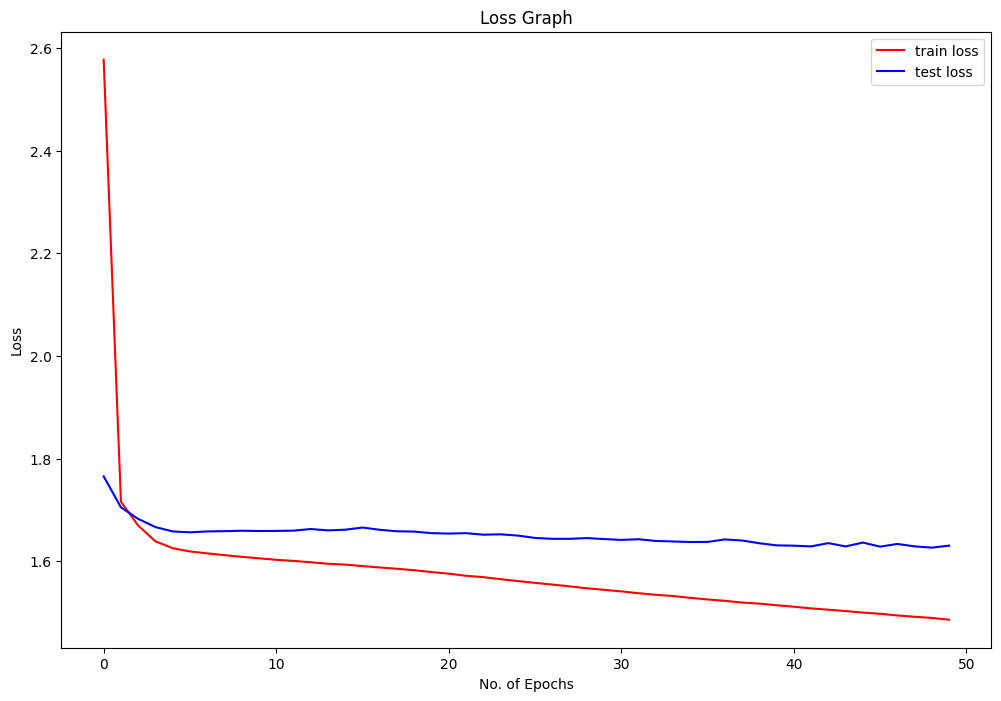

In [ ]:
plt.plot(r.history['loss'],'r',label='train loss')
plt.plot(r.history['val_loss'],'b',label='test loss')
plt.xlabel('No. of Epochs')
plt.ylabel('Loss')
plt.title('Loss Graph')
plt.legend();

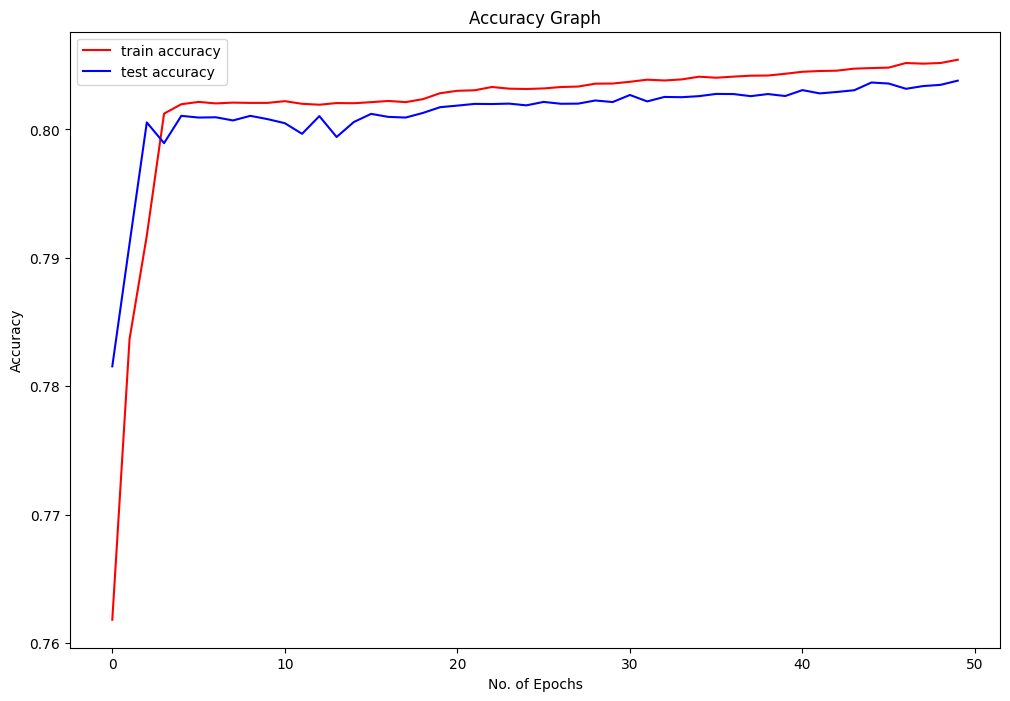

In [ ]:
plt.plot(r.history['accuracy'],'r',label='train accuracy')
plt.plot(r.history['val_accuracy'],'b',label='test accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.legend();

In [ ]:
model.evaluate([X_test,y_test[:,:-1]],y_test.reshape(y_test.shape[0],y_test.shape[1],1)[:,1:])

63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 744ms/step - accuracy: 0.8027 - loss: 1.6386


[1.6301316022872925, 0.8038015961647034]

In [ ]:
model.save('news_article_summary_generator.h5')

In [ ]:
lm = load_model('news_article_summary_generator.h5',custom_objects={'AttentionLayer': AttentionLayer})
lm

<Functional name=functional, built=True>

In [ ]:

encoder_model = Model(inputs=encoder_inputs, outputs=[encoder_outputs, state_h, state_c])

decoder_initial_state_a = Input(shape=(latent_dim,))
decoder_initial_state_c = Input(shape=(latent_dim,))
decoder_hidden_state = Input(shape=(max_text_len, latent_dim))

decoder_out, decoder_state_a, decoder_state_c = decoder_lstm(decoder_emb, initial_state=[decoder_initial_state_a, decoder_initial_state_c])
attn_out_inf, attn_states_inf = attn_layer([decoder_hidden_state, decoder_out])
decoder_inf_concat_outputs = Concatenate(axis=-1, name='concat')([decoder_out, attn_out_inf])

decoder_final = decoder_dense(decoder_inf_concat_outputs)
decoder_model = Model([decoder_inputs]+[decoder_hidden_state, decoder_initial_state_a, decoder_initial_state_c], [decoder_final]+[decoder_state_a, decoder_state_c])

In [ ]:
def decode_sequences(input_sequence):
    encoder_out, encoder_a, encoder_c = encoder_model.predict(input_sequence)
    next_input = np.zeros((1,1))
    next_input[0,0] = y_tokenizer.word_index['start']
    output_sequence = ''
    stop = False
    while not stop:
        decoded_out, trans_state_a, trans_state_c = decoder_model.predict([next_input] + [encoder_out, encoder_a, encoder_c])
        output_idx = np.argmax(decoded_out[0, -1, :])
        if output_idx == y_tokenizer.word_index['end']:
            stop = True
        elif output_idx > 0 and output_idx != y_tokenizer.word_index['start']:
            output_token = y_tokenizer.index_word[output_idx]
            output_sequence = output_sequence + ' ' + output_token
        next_input[0,0] = output_idx
        # Continously update the transient state vectors in decoder.
        encoder_a, encoder_c = trans_state_a, trans_state_c

    return output_sequence

In [ ]:
def sequence_to_text(input_sequence,mode):
    res = ''

    if mode == 'input':
        for idx in input_sequence:
            if idx:
                res = res + x_tokenizer.index_word[idx] + ' '

    elif mode == 'output':
        for idx in input_sequence:
            if idx:
                if y_tokenizer.index_word[idx] != 'start' and y_tokenizer.index_word[idx] != 'end':
                    res = res + y_tokenizer.index_word[idx] + ' '

    return res

In [ ]:
predicted_summaries = []

for i in range(20):
    print("News Article:",sequence_to_text(X_test[i],'input'))
    print("Original Article Summary:",sequence_to_text(y_test[i],'output'))
    pred_summary = decode_sequences(X_test[i].reshape(1,max_text_len))
    print("Predicted Article Summary:",pred_summary)
    predicted_summaries.append(pred_summary)
    print()
    print('---------------------------')
    print()

News Article: indian shuttler saina nehwal posted pictures on her official twitter account of the ring her father gifted her after her bronze medal at the asian games 2018 special gift from papa to me after winning my asian games medal 2018 in jakarta indonesia read nehwal s tweet nehwal became the first indian female shuttler to win an individual asian games medal 
Original Article Summary: saina posts picture of father s gift after asian games medal 
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Article Summary:  i not not not a india in india

---------------------------

News Article: human rights lawyer wang quanzhang has been sentenced to four

In [ ]:
original_summaries = []
references = []

for i in range(20):
    original_summaries.append(sequence_to_text(y_test[i],'output'))

for summary in original_summaries:
    ref = ' '.join(summary.split())
    references.append(ref)

In [ ]:
for i in range(20):
    print("Original News Article Summary:",references[i])
    print("Predicted News Article Summary:",predicted_summaries[i])
    print("BLEU Score:",sentence_bleu(references[i],predicted_summaries[i],weights=(0.25,0.25,0.25,0.25)))
    print("Word Error Rate:",wer(references[i],predicted_summaries[i]))
    print("Match Error Rate:",mer(references[i],predicted_summaries[i]))
    print("Character Error Rate:",cer(references[i],predicted_summaries[i]))
    print("Word Information Preserved:",wip(references[i],predicted_summaries[i]))
    print("Word Information Lost:",wil(references[i],predicted_summaries[i]))
    print('------------------------------------------------------')

Original News Article Summary: saina posts picture of father s gift after asian games medal
Predicted News Article Summary:  i not not not a india in india
BLEU Score: 1.2558634180836711e-231
Word Error Rate: 1.0
Match Error Rate: 1.0
Character Error Rate: 0.7166666666666667
Word Information Preserved: 0.0
Word Information Lost: 1.0
------------------------------------------------------
Original News Article Summary: china jails human rights lawyer for state subversiong
Predicted News Article Summary:  i not not a a a a india
BLEU Score: 1.2882297539194154e-231
Word Error Rate: 1.0
Match Error Rate: 1.0
Character Error Rate: 0.7735849056603774
Word Information Preserved: 0.0
Word Information Lost: 1.0
------------------------------------------------------
Original News Article Summary: censor board chief pahlaj nihalani is a disaster kabir bedi
Predicted News Article Summary:  i not not a a a a india
BLEU Score: 1.3388441433044314e-231
Word Error Rate: 0.9
Match Error Rate: 0.9
Charact

In [ ]:
import pickle
from google.colab import files

# ✅ Save model
model.save('news_article_summary_generator.h5')

# ✅ Save tokenizers
pickle.dump(x_tokenizer, open('x_tokenizer.pkl', 'wb'))
pickle.dump(y_tokenizer, open('y_tokenizer.pkl', 'wb'))

# ✅ Download all three files
files.download('news_article_summary_generator.h5')
files.download('x_tokenizer.pkl')
files.download('y_tokenizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>